In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.metrics import mean_squared_error
from ISLP import load_data

### On the Hitters Dataset

In [2]:
df = load_data('Hitters')
print(df.shape)
df.head()

(322, 20)


,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N


In [3]:
df.isna().sum()

AtBat         0
Hits          0
HmRun         0
Runs          0
RBI           0
Walks         0
Years         0
CAtBat        0
CHits         0
CHmRun        0
CRuns         0
CRBI          0
CWalks        0
League        0
Division      0
PutOuts       0
Assists       0
Errors        0
Salary       59
NewLeague     0
dtype: int64

In [4]:
df.dropna(axis=0, inplace=True) #if any NaN exists, remove that row i.e. axis = 0
df.isna().sum()

AtBat        0
Hits         0
HmRun        0
Runs         0
RBI          0
Walks        0
Years        0
CAtBat       0
CHits        0
CHmRun       0
CRuns        0
CRBI         0
CWalks       0
League       0
Division     0
PutOuts      0
Assists      0
Errors       0
Salary       0
NewLeague    0
dtype: int64

In [ ]:
# Alternate 
# np.where(df['Salary'].isna())[0]
# df.drop(np.where(df['Salary'].isna())[0], axis=0, inplace=True)

In [5]:
df['League'].dtype, df['Division'].dtype, df['NewLeague'].dtype

(CategoricalDtype(categories=['A', 'N'], ordered=False, categories_dtype=object),
 CategoricalDtype(categories=['E', 'W'], ordered=False, categories_dtype=object),
 CategoricalDtype(categories=['A', 'N'], ordered=False, categories_dtype=object))

In [6]:
# df['League'] = (df['League'] == 'A').astype(int) # safer way to label

df['League'] = pd.get_dummies(df['League']).astype(int).iloc[:,0]
df['Division'] = pd.get_dummies(df['Division']).astype(int).iloc[:,0]
df['NewLeague'] = pd.get_dummies(df['NewLeague']).astype(int).iloc[:,0]

# Converts text to integers denoting categories and selects the first column of classification (for League having A and N, so selects the column
# corresponding to classification based on A column. Here A = 1 and N = 0 (alphabet appearing first gets 1)

In [7]:
# Now everything is numeric
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 263 entries, 1 to 321
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   AtBat      263 non-null    int64  
 1   Hits       263 non-null    int64  
 2   HmRun      263 non-null    int64  
 3   Runs       263 non-null    int64  
 4   RBI        263 non-null    int64  
 5   Walks      263 non-null    int64  
 6   Years      263 non-null    int64  
 7   CAtBat     263 non-null    int64  
 8   CHits      263 non-null    int64  
 9   CHmRun     263 non-null    int64  
 10  CRuns      263 non-null    int64  
 11  CRBI       263 non-null    int64  
 12  CWalks     263 non-null    int64  
 13  League     263 non-null    int64  
 14  Division   263 non-null    int64  
 15  PutOuts    263 non-null    int64  
 16  Assists    263 non-null    int64  
 17  Errors     263 non-null    int64  
 18  Salary     263 non-null    float64
 19  NewLeague  263 non-null    int64  
dtypes: float64(1), 

In [8]:
X = df.drop(['Salary'], axis=1)
y = np.log(df['Salary'])

In [9]:
X.shape, y.shape

((263, 19), (263,))

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [16]:
gbr = GradientBoostingRegressor(n_estimators=5000,
                                learning_rate=0.005,
                                max_depth=3,
                                random_state=0)

# gbr = GradientBoostingRegressor(n_estimators=5000,
#                                 random_state=0)

In [18]:
# learning_rate = A shrinkage factor that controls how much each new tree contributes to the final prediction.
# There is a trade-off between learning_rate and n_estimators.
# n_estimators = The number of boosting stages (rounds) to perform. (Larger value usually results in better performance.
# max_depth = Each boosting stage adds a Decision Tree Regressor (weak learner).
# max_depth controls how complex each individual tree can be.
# max_depth=3 means each tree can make at most 3 splits down any branch.
# So each tree is shallow — it captures small, simple patterns or “rules of thumb.”
# This is essential in boosting:
# Many small, simple trees working together → powerful, robust ensemble.
# If you increase max_depth, each tree can fit more complex patterns, but it risks overfitting.

gbr.train_score_
It tracks how the model’s training loss (e.g., MSE) changes as more trees are added.
You can think of it as a “training curve” for the ensemble.
For regression: The default loss is squared error.
So train_score_[m] = current mean squared error on training set after the first (m+1) boosting iterations.

In [19]:
gbr.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.005
,n_estimators,5000
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [20]:
gbr.train_score_ # training loss (MSE) after fiting each of the trees, that is after each boosting rounds (stages)

array([0.7636388 , 0.75752657, 0.75147636, ..., 0.0012446 , 0.00124365,
       0.00124249], shape=(5000,))

In [ ]:
# gbr.train_score_
# It tracks how the model’s training loss (e.g., MSE) changes as more trees are added.
# You can think of it as a “training curve” for the ensemble.
# For regression: The default loss is squared error.
# So train_score_[m] = current mean squared error on training set after the first (m+1) boosting iterations.
# gbr.train_score_[m]=loss on the training data after m+1 trees

In [21]:
# What staged_predict does ?
# In simple terms: It gives us the model’s predictions after each boosting stage, 
# incrementally — as if we stopped training after 1 tree, then 2 trees, then 3, … up to all n_estimators trees.
# If the full Gradient Boosting model is like a “movie” with 5000 frames (trees),
# then staged_predict(X_test) lets you watch each frame — seeing how predictions evolve as new trees are added.
# gbr.staged_predict(X_test) returns the sequence of predicted values after each boosting iteration — useful for plotting test error curves, 
# monitoring overfitting, or implementing manual early stopping.

gbr.staged_predict(X_test)

<generator object GradientBoostingRegressor.staged_predict at 0x000001C4B8E23370>

In [22]:
test_error = np.zeros_like(gbr.train_score_, dtype = float) # test mse (test error)
for i, y_pred in enumerate(gbr.staged_predict(X_test)):
  test_error[i] = mean_squared_error(y_test, y_pred)
test_error

array([0.85336257, 0.8495913 , 0.84400154, ..., 0.17261227, 0.17261402,
       0.1726186 ], shape=(5000,))

In [ ]:
# OR
'''
te = []
for i in gbr.staged_predict(X_test):
    yp = i
    te.append(mean_squared_error(y_test,yp))
te
'''

In [26]:
np.arange(0,5000,1)

array([   0,    1,    2, ..., 4997, 4998, 4999], shape=(5000,))

In [27]:
len(X_test)

53

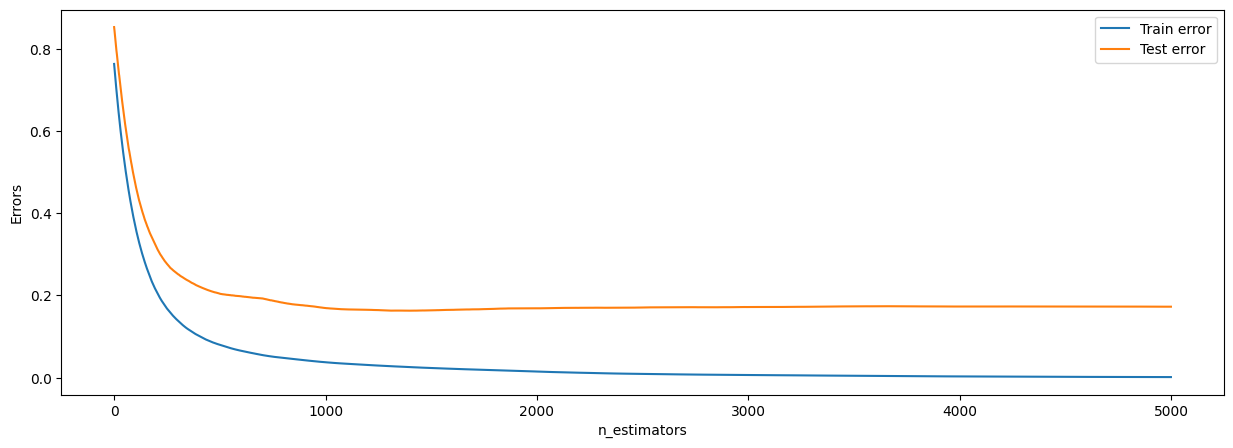

In [28]:
test_error = np.zeros_like(gbr.train_score_, dtype = float)
for idx , y_pr in enumerate(gbr.staged_predict(X_test)):
    test_error[idx] = np.mean(( y_test - y_pr)**2)
plot_idx = np.arange(0,5000,1) # or np.arange(gbr.train_score_.shape[0]) # 5000 n_estiamtors (bagging stages) - creating a numpy array from 0,1,2...4999 (number of boosting stages)
plt.figure(figsize=(15,5))
plt.plot(plot_idx, gbr.train_score_, label='Train error')
plt.plot(plot_idx , test_error , label='Test error')
plt.xlabel('n_estimators')
plt.ylabel('Errors')
plt.legend()
plt.show()

In [29]:
test_error.shape

(5000,)

In [30]:
# As the boosting stages increases, the train and test error falls (better fits the data), then it gets stabilized

In [31]:
y_pred_train = gbr.predict(X_train)
y_pred_test = gbr.predict(X_test)
trn_mse = mean_squared_error(y_train, y_pred_train)
tst_mse = mean_squared_error(y_test, y_pred_test)

print('Train MSE: ', trn_mse)
print('Test MSE: ', tst_mse )

Train MSE:  0.0012424948252975248
Test MSE:  0.17261860481577337


In [32]:
# gbr.predict(X_test) gives Final model’s predictions (after all trees) i.e. used for Evaluating final model

In [33]:
# Trying with different values of h

In [34]:
h = [.001, 0.005, .008, 0.01, 0.05, 0.10, 0.20, 0.40, 0.50]

In [36]:
trn_mse = []
tst_mse = []

for lr in h:
    gbr = GradientBoostingRegressor(n_estimators=5000, learning_rate=lr, random_state=0)
    gbr.fit(X_train, y_train)

    y_pred_train = gbr.predict(X_train)
    y_pred_test = gbr.predict(X_test)

    trn_mse.append(mean_squared_error(y_train, y_pred_train))
    tst_mse.append(mean_squared_error(y_test, y_pred_test))

In [40]:
len(tst_mse)

9

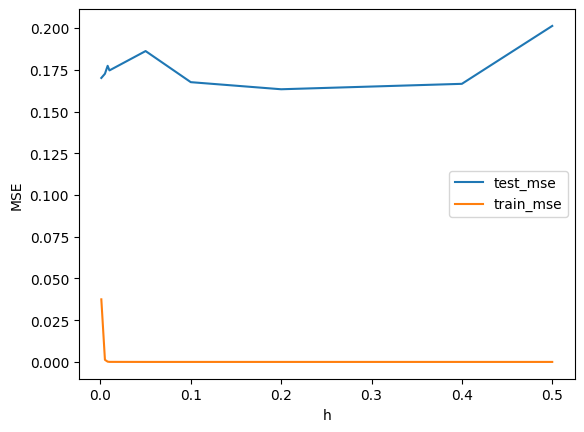

In [37]:
plt.plot(h, tst_mse, label = 'test_mse')
plt.plot(h, trn_mse, label = 'train_mse')
plt.xlabel('h')
plt.ylabel('MSE')
plt.legend()
plt.show()

In [42]:
# Feature Importance
importances = gbr.feature_importances_ # avg decrease in node impurity i.e. it’s a variance (or MSE)-based impurity decrease

In [43]:
importances

array([2.83929215e-02, 9.88229528e-02, 8.95679574e-03, 1.00147455e-02,
       2.08216195e-02, 3.76637193e-02, 2.62697921e-02, 5.69463039e-01,
       4.86195872e-02, 2.39680527e-02, 7.86492102e-03, 8.54208886e-02,
       2.62835871e-03, 1.44904574e-04, 7.01438092e-05, 1.42466429e-02,
       3.15338374e-03, 1.18794283e-02, 1.59810321e-03])

In [45]:
feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by = 'Importance', ascending = False)

print(feat_imp)

      Feature  Importance
7      CAtBat    0.569463
1        Hits    0.098823
11       CRBI    0.085421
8       CHits    0.048620
5       Walks    0.037664
0       AtBat    0.028393
6       Years    0.026270
9      CHmRun    0.023968
4         RBI    0.020822
15    PutOuts    0.014247
17     Errors    0.011879
3        Runs    0.010015
2       HmRun    0.008957
10      CRuns    0.007865
16    Assists    0.003153
12     CWalks    0.002628
18  NewLeague    0.001598
13     League    0.000145
14   Division    0.000070


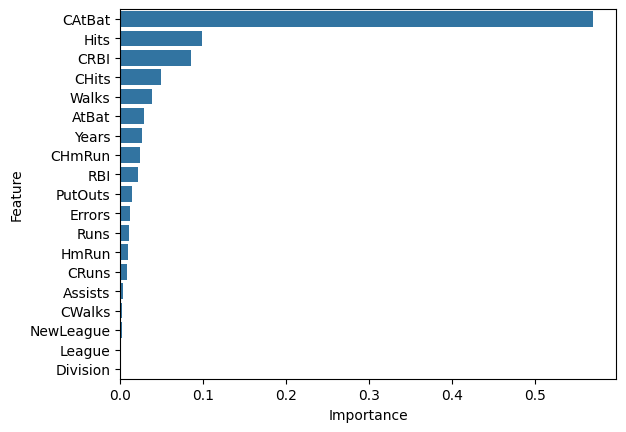

In [46]:
import seaborn as sns

sns.barplot(x = feat_imp['Importance'], y = feat_imp['Feature'])
plt.show()

### On the Boston Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.metrics import mean_squared_error
from ISLP import load_data

In [2]:
boston = load_data('Boston')
boston.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


In [3]:
X = boston.drop(['medv'], axis = 1)
Y = boston['medv']

In [4]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.20, random_state=0)

In [6]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((404, 12), (102, 12), (404,), (102,))

In [7]:
gbr = GradientBoostingRegressor(n_estimators = 5000, learning_rate=0.005, max_depth=3, random_state=0)
# can select n_estimators, max_depth, learning_rate by cv (time-consuming)
"""
kf = KFold(n_splits = 5, shuffle=True, random_state=0)
grid = GridSearchCV(g,
                    param_grid={'n_estimators':[1000,2000,3000,4000,5000,6000],
                        'learning_rate':[0.001,0.002,0.005,0.02,0.05],
                                'max_depth': [2,3,4,5]},
                    scoring = 'neg_mean_squared_error',
                    cv = kf,
                    n_jobs=-1)
grid.fit(x_train, y_train)

grid.best_params_
"""
gbr.fit(x_train, y_train)

,loss,'squared_error'
,learning_rate,0.005
,n_estimators,5000
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


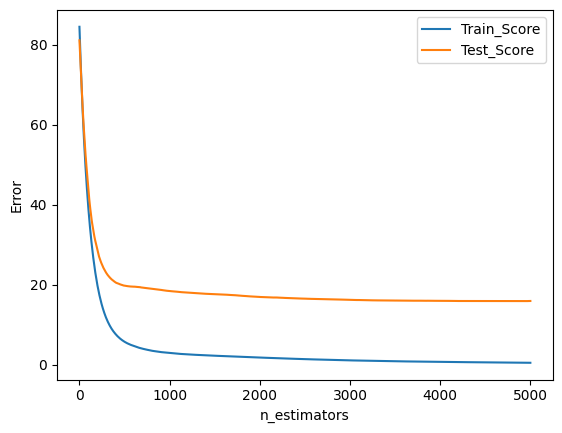

In [8]:
train_scores = gbr.train_score_
test_score = np.zeros_like(train_scores, dtype = float)
for i,y_pr in enumerate(gbr.staged_predict(x_test)):
  test_score[i] = mean_squared_error(y_test, y_pr)
plt_idx = np.arange(gbr.train_score_.shape[0])
plt.plot(plt_idx, train_scores, label = 'Train_Score')
plt.plot(plt_idx, test_score, label = 'Test_Score')
plt.xlabel('n_estimators')
plt.ylabel('Error')
plt.legend()
plt.show()

In [9]:
y_pred_train = gbr.predict(x_train)
y_pred_test = gbr.predict(x_test)
train_mse = mean_squared_error(y_train, y_pred_train)
test_mse = mean_squared_error(y_test, y_pred_test)
print('Train Mse: ', train_mse)
print('Test MSe: ', test_mse)

Train Mse:  0.4799185805014061
Test MSe:  15.922247450082414


In [10]:
df = pd.DataFrame({'Feature': X.columns, 'Importance':gbr.feature_importances_}).sort_values(ascending = False, by = 'Importance')
df.head()

,Feature,Importance
11,lstat,0.489911
5,rm,0.309581
10,ptratio,0.054403
7,dis,0.054011
0,crim,0.036516


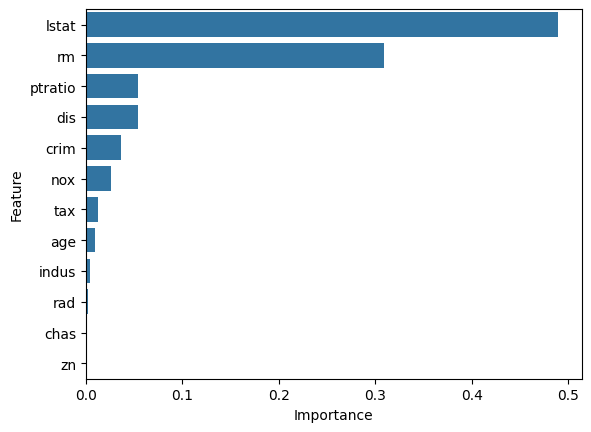

In [11]:
import seaborn as sns
sns.barplot(x = df['Importance'], y = df['Feature'])
plt.show()

### On the Breast Cancer Dataset

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.datasets import load_breast_cancer

In [13]:
data = load_breast_cancer()
breast_cancer = pd.DataFrame(data = data.data, columns= data.feature_names)
breast_cancer['Target'] = data.target
breast_cancer.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [14]:
X = breast_cancer.drop(['Target'], axis = 1)
Y = breast_cancer['Target']

In [15]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.20, random_state=0)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((455, 30), (114, 30), (455,), (114,))

In [16]:
gbr = GradientBoostingClassifier(n_estimators=5000, learning_rate=0.005, max_depth=3, random_state=0)
gbr.fit(x_train, y_train)

,loss,'log_loss'
,learning_rate,0.005
,n_estimators,5000
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


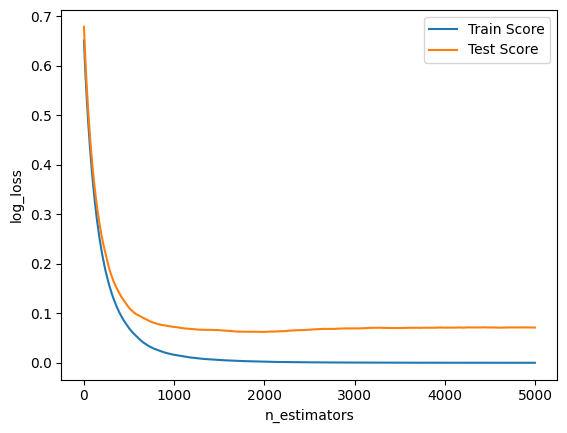

In [17]:
from sklearn.metrics import log_loss
# to obtain the plot of log loss ag the boosting stages (by default GradientBoostingClassifier loss = 'log loss')
# train_score = gbr.train_score_ #gives the train log loss after each boosting stage
train_score = np.zeros_like(gbr.train_score_, dtype = float)
for i, y_prob in enumerate(gbr.staged_predict_proba(x_train)):
  train_score[i] = log_loss(y_train, y_prob)
# The Gradient Boosting Classifier builds an ensemble of weak learners (decision trees) 
# sequentially — each one trying to fix the errors of the previous.

After adding each tree, the model can make a partial prediction using all trees built so far.
test_score = np.zeros_like(train_score, dtype = float)
for i, y_prob in enumerate(gbr.staged_predict_proba(x_test)):
  test_score[i] = log_loss(y_test, y_prob)

plot_idx = np.arange(train_score.shape[0])
plt.plot(plot_idx, train_score, label = 'Train Score')
plt.plot(plot_idx, test_score, label = 'Test Score')
plt.xlabel('n_estimators'); plt.ylabel('log_loss')
plt.legend()
plt.show()

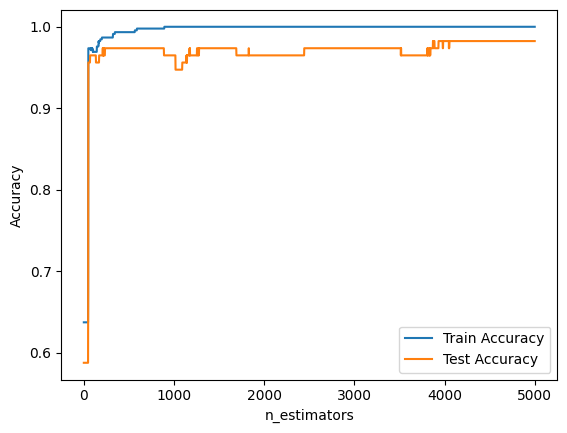

In [21]:
from sklearn.metrics import accuracy_score
train_acc = np.zeros_like(gbr.train_score_, dtype=float)
# gbr.staged_predict(X) gives the evolving predicted labels after each 
# boosting stage — useful for plotting how accuracy changes as the model adds more trees.
# gbr.staged_predict(X) gives the evolving predicted labels after each boosting stage — useful for 
# plotting how accuracy changes as the model adds more trees.
for i, y_pred in enumerate(gbr.staged_predict(x_train)):
    train_acc[i] = accuracy_score(y_train, y_pred)

test_acc = np.zeros_like(train_acc, dtype = float)
for i, y_pred in enumerate(gbr.staged_predict(x_test)):
    test_acc[i] = accuracy_score(y_test, y_pred)

plot_idx = np.arange(train_acc.shape[0])
plt.plot(plot_idx, train_acc, label = 'Train Accuracy')
plt.plot(plot_idx, test_acc, label = 'Test Accuracy')
plt.xlabel('n_estimators'); plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [22]:
# train and test accuracy

# gbr.predict(X) - This gives the final predicted class labels for the data X,
# after all boosting iterations (all trees) have been trained and combined.
# Here: y_pred is a NumPy array of shape (n_samples,)
# Each element is the final predicted class for that sample — for example 0 or 1 in binary classification.
# Internally - The model computes the final decision function (sum of contributions from all 5000 trees).
# For classification, it converts that into class probabilities, then picks the class with the highest probability.

y_pred_tr = gbr.predict(x_train)
train_acc = accuracy_score(y_train, y_pred_tr)

y_pred_test = gbr.predict(x_test)
test_acc = accuracy_score(y_test, y_pred_test)

print(f'Train Acc : {train_acc}')
print(f'Test Acc : {test_acc}')

Train Acc : 1.0
Test Acc : 0.9824561403508771


In [24]:
# feature importance
df = pd.DataFrame({'Features':X.columns, 'Importance':gbr.feature_importances_}).sort_values(by = 'Importance', ascending=False)
df

,Features,Importance
27,worst concave points,0.426370
7,mean concave points,0.277158
23,worst area,0.091310
22,worst perimeter,0.051327
21,worst texture,0.032751
13,area error,0.025141
20,worst radius,0.018404
1,mean texture,0.013629
26,worst concavity,0.012378
4,mean smoothness,0.011397


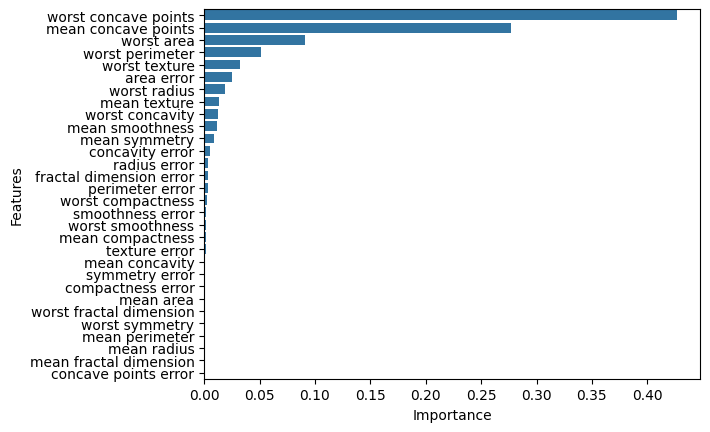

In [25]:
import seaborn as sns
sns.barplot(x = df['Importance'], y = df['Features'])
plt.show()